# Adversarial Validation — Train vs Test Shift

Detects distribution shift between `train.csv` and competition `test.csv` using the **same feature pipeline** as `models copy.ipynb` / `feature_eng.ipynb`.

- **Label:** `is_test = 0` (train), `is_test = 1` (test)
- **Features:** all engineered columns; excludes `client_id`, `default`, and the label itself
- **Model:** simple XGBoost classifier (not the tuned competition model)
- **Evaluation:** 5-fold stratified CV, ROC-AUC

Does **not** use `default` and does **not** modify competition test data.

## 1. Imports and paths

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from model_copy_utils import RANDOM_STATE, CV_FOLDS, load_data, get_feature_sets
from feature_eng_lib import engineer_all_features

SHIFT_RANDOM_STATE = 42
SHIFT_CV_FOLDS = 5
SHIFT_AUC_MATERIAL_THRESHOLD = 0.55
TOP_IMPORTANCE_N = 20
TEST_LIKE_TOP_FRAC = 0.10

c:\Users\Nick\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and engineer features

Uses `engineer_all_features()` — base models-copy engineering plus feature_eng blocks.

In [2]:
train_df = engineer_all_features(load_data("train.csv"))
test_df = engineer_all_features(load_data("test.csv"))

EXCLUDE_COLS = ["client_id", "default"]
SHIFT_FEATURE_COLS = [c for c in train_df.columns if c not in EXCLUDE_COLS]

missing_in_test = [c for c in SHIFT_FEATURE_COLS if c not in test_df.columns]
if missing_in_test:
    raise ValueError(f"Test set missing engineered columns: {missing_in_test}")

FEATURE_SETS = get_feature_sets(SHIFT_FEATURE_COLS)

print(f"train rows: {len(train_df):,}")
print(f"test rows:  {len(test_df):,}")
print(f"shift features: {len(SHIFT_FEATURE_COLS)}")
print(f"all_engineered_extended (models copy): {len(FEATURE_SETS['all_engineered_extended'])} cols")

train rows: 24,000
test rows:  6,000
shift features: 82
all_engineered_extended (models copy): 82 cols


## 3. Build combined adversarial dataset

Read-only use of test features — no writes back to `test_df`.

In [3]:
train_adv = train_df[SHIFT_FEATURE_COLS].copy()
train_adv["is_test"] = 0
train_adv["client_id"] = train_df["client_id"].values

test_adv = test_df[SHIFT_FEATURE_COLS].copy()
test_adv["is_test"] = 1
test_adv["client_id"] = test_df["client_id"].values

adv_df = pd.concat([train_adv, test_adv], ignore_index=True)

X_adv = adv_df[SHIFT_FEATURE_COLS]
y_adv = adv_df["is_test"]

print(adv_df["is_test"].value_counts().rename({0: "train", 1: "test"}))
print(f"\nCombined shape: {adv_df.shape}")

is_test
train    24000
test      6000
Name: count, dtype: int64

Combined shape: (30000, 84)


## 4. Shift classifier — 5-fold CV ROC-AUC

Simple untuned XGBoost (separate from the competition tuned model).

In [4]:
shift_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=SHIFT_RANDOM_STATE,
    n_jobs=-1,
)

shift_cv = StratifiedKFold(
    n_splits=SHIFT_CV_FOLDS,
    shuffle=True,
    random_state=SHIFT_RANDOM_STATE,
)

fold_aucs = []
for fold_idx, (train_idx, val_idx) in enumerate(shift_cv.split(X_adv, y_adv), start=1):
    fold_model = clone(shift_model)
    fold_model.fit(X_adv.iloc[train_idx], y_adv.iloc[train_idx])
    val_prob = fold_model.predict_proba(X_adv.iloc[val_idx])[:, 1]
    fold_auc = roc_auc_score(y_adv.iloc[val_idx], val_prob)
    fold_aucs.append(fold_auc)
    print(f"Fold {fold_idx} ROC-AUC: {fold_auc:.6f}")

shift_auc_mean = float(np.mean(fold_aucs))
shift_auc_std = float(np.std(fold_aucs))

print(f"\nMean ROC-AUC: {shift_auc_mean:.6f}")
print(f"Std  ROC-AUC: {shift_auc_std:.6f}")
print(
    f"Material shift (>{SHIFT_AUC_MATERIAL_THRESHOLD}): "
    f"{shift_auc_mean > SHIFT_AUC_MATERIAL_THRESHOLD}"
)

Fold 1 ROC-AUC: 0.507838
Fold 2 ROC-AUC: 0.498132
Fold 3 ROC-AUC: 0.514127
Fold 4 ROC-AUC: 0.515605
Fold 5 ROC-AUC: 0.507883

Mean ROC-AUC: 0.508717
Std  ROC-AUC: 0.006168
Material shift (>0.55): False


## 5. Out-of-fold probabilities

In [5]:
oof_test_prob = cross_val_predict(
    shift_model,
    X_adv,
    y_adv,
    cv=shift_cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

adv_df = adv_df.copy()
adv_df["oof_test_prob"] = oof_test_prob

train_oof = adv_df[adv_df["is_test"] == 0][["client_id", "oof_test_prob"]]
test_oof = adv_df[adv_df["is_test"] == 1][["client_id", "oof_test_prob"]]

print("OOF probability summary (all rows):")
print(adv_df.groupby("is_test")["oof_test_prob"].describe())

print("\nTrain rows OOF (first 5):")
print(train_oof.head())

print("\nTest rows OOF (first 5):")
print(test_oof.head())

OOF probability summary (all rows):
           count      mean       std       min       25%       50%       75%  \
is_test                                                                        
0        24000.0  0.198972  0.041062  0.047364  0.173953  0.196103  0.220563   
1         6000.0  0.199257  0.040833  0.055720  0.174205  0.196506  0.221472   

              max  
is_test            
0        0.548442  
1        0.440830  

Train rows OOF (first 5):
         client_id  oof_test_prob
0  CC_0000F52C3717       0.155225
1  CC_0008C4E44BB9       0.183075
2  CC_000B4B1BEDF6       0.176465
3  CC_000D492CE7AD       0.223710
4  CC_000DCFA992C4       0.209045

Test rows OOF (first 5):
             client_id  oof_test_prob
24000  CC_0012A082B7B7       0.197228
24001  CC_0012BC27DFB6       0.250993
24002  CC_001563B2143D       0.138701
24003  CC_001B46930B6F       0.194539
24004  CC_001D771E1C9F       0.207286


## 6. Feature importance (top 20)

Fit on the full combined dataset for a single global importance view.

Top 20 shift features:
            feature  importance
 num_months_delayed    0.016725
              PAY_4    0.015847
    older_delay_avg    0.015342
          mean_util    0.014742
        max_pay_amt    0.014718
                SEX    0.014686
           PAY_AMT3    0.014609
      credit_util_3    0.014431
           MARRIAGE    0.014369
          BILL_AMT2    0.014345
      credit_util_5    0.014316
      credit_util_1    0.014117
       old_pay_mean    0.014079
   pay_bill_ratio_5    0.013952
          total_pay    0.013934
      credit_util_6    0.013859
          BILL_AMT4    0.013694
          BILL_AMT3    0.013595
bill_pct_change_4_5    0.013559
           max_util    0.013467


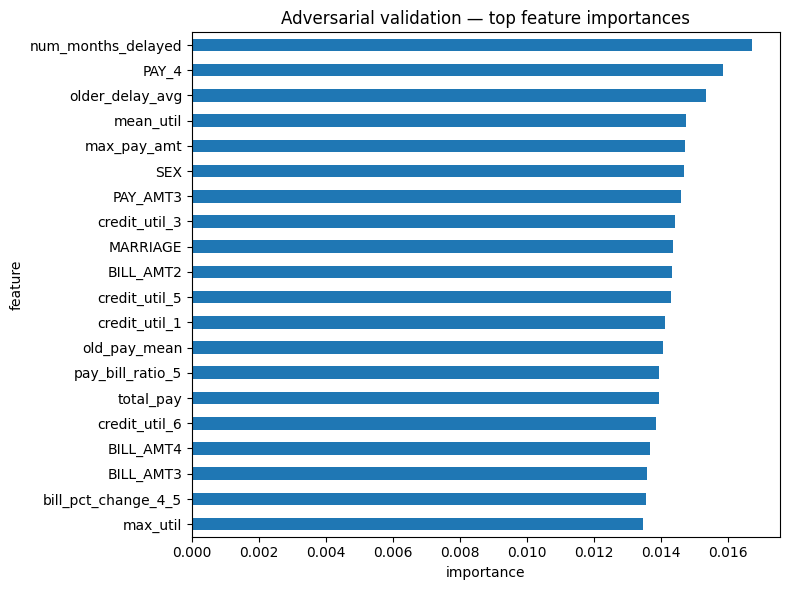

,feature,importance
0,num_months_delayed,0.016725
1,PAY_4,0.015847
2,older_delay_avg,0.015342
3,mean_util,0.014742
4,max_pay_amt,0.014718
5,SEX,0.014686
6,PAY_AMT3,0.014609
7,credit_util_3,0.014431
8,MARRIAGE,0.014369
9,BILL_AMT2,0.014345


In [6]:
shift_model.fit(X_adv, y_adv)

importance = pd.Series(
    shift_model.feature_importances_,
    index=SHIFT_FEATURE_COLS,
    name="importance",
).sort_values(ascending=False)

top_importance = importance.head(TOP_IMPORTANCE_N).reset_index()
top_importance.columns = ["feature", "importance"]

print(f"Top {TOP_IMPORTANCE_N} shift features:")
print(top_importance.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
top_importance.sort_values("importance").plot.barh(
    x="feature", y="importance", ax=ax, legend=False
)
ax.set_title("Adversarial validation — top feature importances")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

top_importance

## 7. Test-like training rows (if shift is material)

When mean ROC-AUC is materially above 0.5, inspect training rows with the highest OOF `P(is_test)`.

In [7]:
if shift_auc_mean > SHIFT_AUC_MATERIAL_THRESHOLD:
    n_top = max(1, int(len(train_oof) * TEST_LIKE_TOP_FRAC))
    test_like_train = train_oof.sort_values("oof_test_prob", ascending=False).head(n_top)

    print(
        f"Shift AUC {shift_auc_mean:.4f} > {SHIFT_AUC_MATERIAL_THRESHOLD} — "
        f"analysing top {TEST_LIKE_TOP_FRAC:.0%} test-like train rows ({n_top} rows)"
    )
    print("\nOOF P(is_test) summary — all train rows:")
    print(train_oof["oof_test_prob"].describe())
    print("\nOOF P(is_test) summary — top test-like train rows:")
    print(test_like_train["oof_test_prob"].describe())
    print("\nTop 10 test-like train rows:")
    print(test_like_train.head(10).to_string(index=False))

    test_like_train
else:
    print(
        f"Shift AUC {shift_auc_mean:.4f} is not materially above 0.5 "
        f"(threshold {SHIFT_AUC_MATERIAL_THRESHOLD}). Skipping test-like row analysis."
    )

Shift AUC 0.5087 is not materially above 0.5 (threshold 0.55). Skipping test-like row analysis.
